In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score
import itertools

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

import pandas as pd

**1. Перебор параметров для оригинальной модели**

In [28]:
@dataclass
class Config:
    image_size: tuple = (128, 128)
    batch_size: int = 8
    epochs: int = 10
    learning_rate: float = 0.1
    train_split: float = 0.8
    device = "cuda" if torch.cuda.is_available() else "cpu"

    def __repr__(self):
        return (f"Config(image_size={self.image_size}, "
                f"batch_size={self.batch_size}, "
                f"epochs={self.epochs}, "
                f"learning_rate={self.learning_rate}, "
                f"device={self.device}, "
                f"train_split={self.train_split})")

params = {
    "lr" : [0.1, 0.01, 0.001],
    "batch_size" : [8, 16, 32],
    "epochs" : [10],
}

**2. Реализация оригинальной модели**

In [2]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2) #padding=1)

        # тут слои обозначить для encoder
        self.encoder_layer_1 = self.ConvBlock(in_channels, 64)
        self.encoder_layer_2 = self.ConvBlock(64, 128)
        self.encoder_layer_3 = self.ConvBlock(128, 256)
        self.encoder_layer_4 = self.ConvBlock(256, 512)

        # bottleneck
        self.bottleneck_layer = self.ConvBlock(512, 1024)

        # decoder
        self.decoder_layer_1 = self.ConvBlock(1024, 512)
        self.upscale_1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)

        self.decoder_layer_2 = self.ConvBlock(512, 256)
        self.upscale_2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)

        self.decoder_layer_3 = self.ConvBlock(256, 128)
        self.upscale_3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)

        self.decoder_layer_4 = self.ConvBlock(128, 64)
        self.upscale_4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)

        self.fc1 = nn.Conv2d(64, out_channels, kernel_size=1)

    def ConvBlock(self, in_channels, out_channels):
      return nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          #nn.MaxPool()
      )

    def forward(self, x):
        # тут предсказать маску
        e_layer_1 = self.encoder_layer_1(x)
        e_layer_2 = self.encoder_layer_2(self.maxpool(e_layer_1))
        e_layer_3 = self.encoder_layer_3(self.maxpool(e_layer_2))
        e_layer_4 = self.encoder_layer_4(self.maxpool(e_layer_3))

        b_layer = self.bottleneck_layer(self.maxpool(e_layer_4))

        d_layer_1 = self.upscale_1(b_layer)
        d_layer_1 = torch.cat([d_layer_1, e_layer_4], dim=1)
        d_layer_1 = self.decoder_layer_1(d_layer_1)

        d_layer_2 = self.upscale_2(d_layer_1)
        d_layer_2 = torch.cat([d_layer_2, e_layer_3], dim=1)
        d_layer_2 = self.decoder_layer_2(d_layer_2)

        d_layer_3 = self.upscale_3(d_layer_2)
        d_layer_3 = torch.cat([d_layer_3, e_layer_2], dim=1)
        d_layer_3 = self.decoder_layer_3(d_layer_3)

        d_layer_4 = self.upscale_4(d_layer_3)
        d_layer_4 = torch.cat([d_layer_4, e_layer_1], dim=1)
        d_layer_4 = self.decoder_layer_4(d_layer_4)

        return self.fc1(d_layer_4)

**3. Реализация модели с нормализацией слоев**

In [3]:
class UNet_norm(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet_norm, self).__init__()

        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2) #padding=1)

        # тут слои обозначить для encoder
        self.encoder_layer_1 = self.ConvBlock(in_channels, 64)
        self.encoder_layer_2 = self.ConvBlock(64, 128)
        self.encoder_layer_3 = self.ConvBlock(128, 256)
        self.encoder_layer_4 = self.ConvBlock(256, 512)

        # bottleneck
        self.bottleneck_layer = self.ConvBlock(512, 1024)

        # decoder
        self.decoder_layer_1 = self.ConvBlock(1024, 512)
        self.upscale_1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)

        self.decoder_layer_2 = self.ConvBlock(512, 256)
        self.upscale_2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)

        self.decoder_layer_3 = self.ConvBlock(256, 128)
        self.upscale_3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)

        self.decoder_layer_4 = self.ConvBlock(128, 64)
        self.upscale_4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)

        self.fc1 = nn.Conv2d(64, out_channels, kernel_size=1)

    def ConvBlock(self, in_channels, out_channels):
      return nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
          nn.BatchNorm2d(out_channels),
          nn.ReLU(inplace=True),
          nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
          nn.BatchNorm2d(out_channels),
          nn.ReLU(inplace=True),
          #nn.MaxPool()
      )

    def forward(self, x):
        # тут предсказать маску
        e_layer_1 = self.encoder_layer_1(x)
        e_layer_2 = self.encoder_layer_2(self.maxpool(e_layer_1))
        e_layer_3 = self.encoder_layer_3(self.maxpool(e_layer_2))
        e_layer_4 = self.encoder_layer_4(self.maxpool(e_layer_3))

        b_layer = self.bottleneck_layer(self.maxpool(e_layer_4))

        d_layer_1 = self.upscale_1(b_layer)
        d_layer_1 = torch.cat([d_layer_1, e_layer_4], dim=1)
        d_layer_1 = self.decoder_layer_1(d_layer_1)

        d_layer_2 = self.upscale_2(d_layer_1)
        d_layer_2 = torch.cat([d_layer_2, e_layer_3], dim=1)
        d_layer_2 = self.decoder_layer_2(d_layer_2)

        d_layer_3 = self.upscale_3(d_layer_2)
        d_layer_3 = torch.cat([d_layer_3, e_layer_2], dim=1)
        d_layer_3 = self.decoder_layer_3(d_layer_3)

        d_layer_4 = self.upscale_4(d_layer_3)
        d_layer_4 = torch.cat([d_layer_4, e_layer_1], dim=1)
        d_layer_4 = self.decoder_layer_4(d_layer_4)

        return self.fc1(d_layer_4)

In [4]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [5]:
class Trainer:
    def __init__(self, config, model=UNet()):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = model.to(config.device)
        self.criterion = nn.BCEWithLogitsLoss() # лосс = sigmoid & BCE
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [ ]:
keys = params.keys()
values = params.values()
param_combinations = list(itertools.product(*values))

print("Комбинации параметров:")
for combo in param_combinations:
    print(dict(zip(keys, combo)))

aggreg_result = []

for i, combo in enumerate(param_combinations):
    print(f"\n{' '*50}")
    print(f">> Вариант {i+1}")
    print(f"  Параметры: {dict(zip(keys, combo))}")
    print(' '*50)

    config = Config()
    for key, value in zip(keys, combo):
        setattr(config, key, value)

    trainer = Trainer(config)

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_iou': [],
        'val_f1': []
    }

    for epoch in range(config.epochs):
        train_loss = trainer.train()
        val_loss, val_iou, val_f1 = trainer.validate()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_f1'].append(val_f1)

        print(f"Epoch {epoch+1}/{config.epochs}: "
              f"train_loss: {train_loss:.4f}, "
              f"val_iou: {val_iou:.4f}")

    test_loss, test_iou, test_f1 = trainer.test()

    result = {
        'experiment_id': i,
        **dict(zip(keys, combo)),
        'test_loss': test_loss,
        'test_iou': test_iou,
        'test_f1': test_f1,
        'history': history
    }

    aggreg_result.append(result)

    print(f"\n  Результаты эксперимента {i + 1}:")
    print(f"    Test IoU: {test_iou:.3f}")
    print(f"    Test F1: {test_f1:.3f}\n")

Комбинации параметров:
{'lr': 0.1, 'batch_size': 8, 'epochs': 10}
{'lr': 0.1, 'batch_size': 16, 'epochs': 10}
{'lr': 0.1, 'batch_size': 32, 'epochs': 10}
{'lr': 0.01, 'batch_size': 8, 'epochs': 10}
{'lr': 0.01, 'batch_size': 16, 'epochs': 10}
{'lr': 0.01, 'batch_size': 32, 'epochs': 10}
{'lr': 0.001, 'batch_size': 8, 'epochs': 10}
{'lr': 0.001, 'batch_size': 16, 'epochs': 10}
{'lr': 0.001, 'batch_size': 32, 'epochs': 10}

                                                  
>> Вариант 1
  Параметры: {'lr': 0.1, 'batch_size': 8, 'epochs': 10}
                                                  


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:16<00:00,  5.47it/s]


Epoch 1/10: train_loss: 0.5185, val_iou: 0.7110


100%|██████████| 92/92 [00:13<00:00,  7.06it/s]


Epoch 2/10: train_loss: 0.4379, val_iou: 0.7644


...

Epoch 9/10: train_loss: 0.3120, val_iou: 0.8178


100%|██████████| 23/23 [00:11<00:00,  1.98it/s]


Epoch 10/10: train_loss: 0.2925, val_iou: 0.8331


100%|██████████| 115/115 [00:59<00:00,  1.95it/s]


  Результаты эксперимента 9:
    Test IoU: 0.831
    Test F1: 0.901



In [ ]:
results_df = pd.DataFrame([
    {
        'Вариант #': r['experiment_id'] + 1,
        'learning_rate': r['lr'],
        'batch_size': r['batch_size'],
        'epochs': r['epochs'],
        'test_iou': r['test_iou'],
        'test_f1': r['test_f1']
    }
    for r in aggreg_result
])

print(results_df.to_string(index=False))

# best by iou
best_by_iou = results_df.loc[results_df['test_iou'].idxmax()]
print(f"\nЛучшая конфигурация по IoU:")
print(f"  learning_rate: {best_by_iou['learning_rate']}")
print(f"  batch_size: {best_by_iou['batch_size']}")
print(f"  epochs: {best_by_iou['epochs']}\n")
print(f"  IoU: {best_by_iou['test_iou']:.4f}")

# best by f1
best_by_iou = results_df.loc[results_df['test_f1'].idxmax()]
print(f"\nЛучшая конфигурация по F1:")
print(f"  learning_rate: {best_by_iou['learning_rate']}")
print(f"  batch_size: {best_by_iou['batch_size']}")
print(f"  epochs: {best_by_iou['epochs']}\n")
print(f"  F1: {best_by_iou['test_f1']:.4f}")


 Вариант #  learning_rate  batch_size  epochs  test_iou  test_f1
         1          0.100           8      10  0.858366 0.918832
         2          0.100          16      10  0.851762 0.914646
         3          0.100          32      10  0.805764 0.885982
         4          0.010           8      10  0.858506 0.918477
         5          0.010          16      10  0.852908 0.915025
         6          0.010          32      10  0.812324 0.890402
         7          0.001           8      10  0.857075 0.917650
         8          0.001          16      10  0.838979 0.906151
         9          0.001          32      10  0.830511 0.901308

Лучшая конфигурация по IoU:
  learning_rate: 0.01
  batch_size: 8.0
  epochs: 10.0

  IoU: 0.8585

Лучшая конфигурация по F1:
  learning_rate: 0.1
  batch_size: 8.0
  epochs: 10.0

  F1: 0.9188


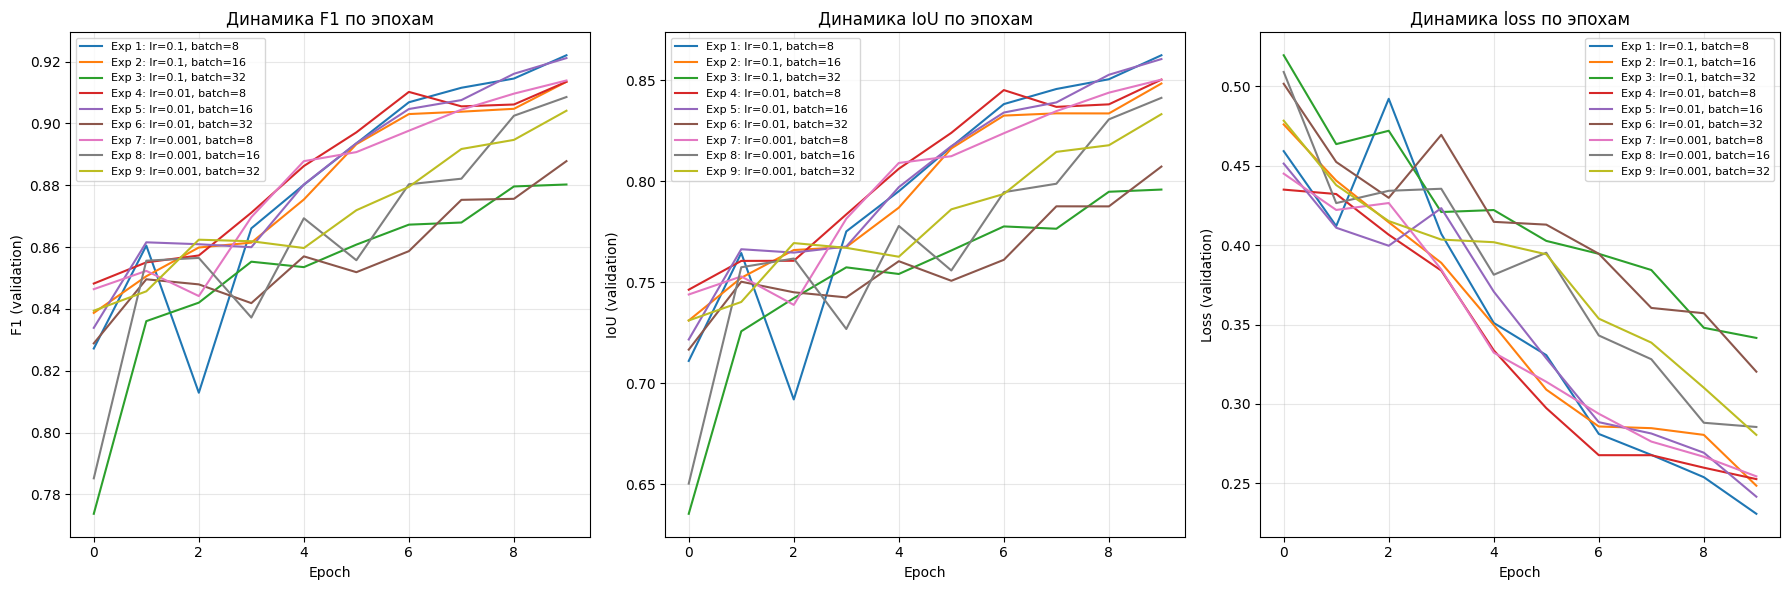

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
results_df = pd.DataFrame([
    {
        'experiment_id': i,
        'lr': result['lr'],
        'batch_size': result['batch_size'],
        'test_iou': result['test_iou'],
        'test_f1': result['test_f1']
    }
    for i, result in enumerate(aggreg_result)
])

# f1 vs epoch
for i, result in enumerate(aggreg_result):
    axes[0].plot(result['history']['val_f1'],
                    label=f"Exp {i+1}: lr={result['lr']}, batch={result['batch_size']}")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('F1 (validation)')
axes[0].set_title('Динамика F1 по эпохам')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)

# iou vs epoch
for i, result in enumerate(aggreg_result):
    axes[1].plot(result['history']['val_iou'],
                    label=f"Exp {i+1}: lr={result['lr']}, batch={result['batch_size']}")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU (validation)')
axes[1].set_title('Динамика IoU по эпохам')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

# loss vs epoch
for i, result in enumerate(aggreg_result):
    axes[2].plot(result['history']['val_loss'],
                    label=f"Exp {i+1}: lr={result['lr']}, batch={result['batch_size']}")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (validation)')
axes[2].set_title('Динамика loss по эпохам')
axes[2].legend(loc='best', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод по сравнению параметров:** Удивительно, но наилучший набор параметров для модели - lr = 0.01, batch_size = 8. Выбор малого размера batch_size можно объяснить тем, что в оригинальной реализации UNet нет нормализации в convblock'e, поэтому большие размеры батча приводят к переобучению и падению метрик (слишком точные значения).
Количество эпох ограничено десятком, поэтому при малом lr, модель не успевает сойтись → лучший результат показывает шаг 0.01

**4. Сравнение двух моделей с идентичными параметрами**

In [9]:
def compare_c():
  compare_config = Config()

  chosen_params = {
      'lr' : 0.01,
      'batch_size' : 8,
      'epochs' : 10
  }

  for key, value in chosen_params.items():
    setattr(compare_config, key, value)

  return compare_config

trainer_without = Trainer(config=compare_c(), model=UNet())
trainer_with = Trainer(config=compare_c(), model=UNet_norm())

history_without = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
        'val_f1': []
    }

history_with = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_f1': []
}

epochs = 10

for epoch in range(epochs):
  train_loss = trainer_without.train()
  val_loss, val_iou, val_f1 = trainer_without.validate()

  history_without['train_loss'].append(train_loss)
  history_without['val_loss'].append(val_loss)
  history_without['val_iou'].append(val_iou)
  history_without['val_f1'].append(val_f1)

  print(f"Epoch {epoch+1}/10: "
              f"train_loss: {train_loss:.4f}, "
              f"val_iou: {val_iou:.4f}")

for epoch in range(epochs):
  train_loss = trainer_with.train()
  val_loss, val_iou, val_f1 = trainer_with.validate()

  history_with['train_loss'].append(train_loss)
  history_with['val_loss'].append(val_loss)
  history_with['val_iou'].append(val_iou)
  history_with['val_f1'].append(val_f1)

  print(f"Epoch {epoch+1}/10: "
              f"train_loss: {train_loss:.4f}, "
              f"val_iou: {val_iou:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:13<00:00,  7.03it/s]


Epoch 1/10: train_loss: 0.5313, val_iou: 0.7468


100%|██████████| 92/92 [00:13<00:00,  7.06it/s]


Epoch 2/10: train_loss: 0.4293, val_iou: 0.7494


100%|██████████| 92/92 [00:12<00:00,  7.12it/s]


...

Epoch 8/10: train_loss: 0.1701, val_iou: 0.8906


100%|██████████| 92/92 [00:12<00:00,  7.28it/s]


Epoch 9/10: train_loss: 0.1585, val_iou: 0.8950


100%|██████████| 92/92 [00:12<00:00,  7.36it/s]

Epoch 10/10: train_loss: 0.1434, val_iou: 0.8870


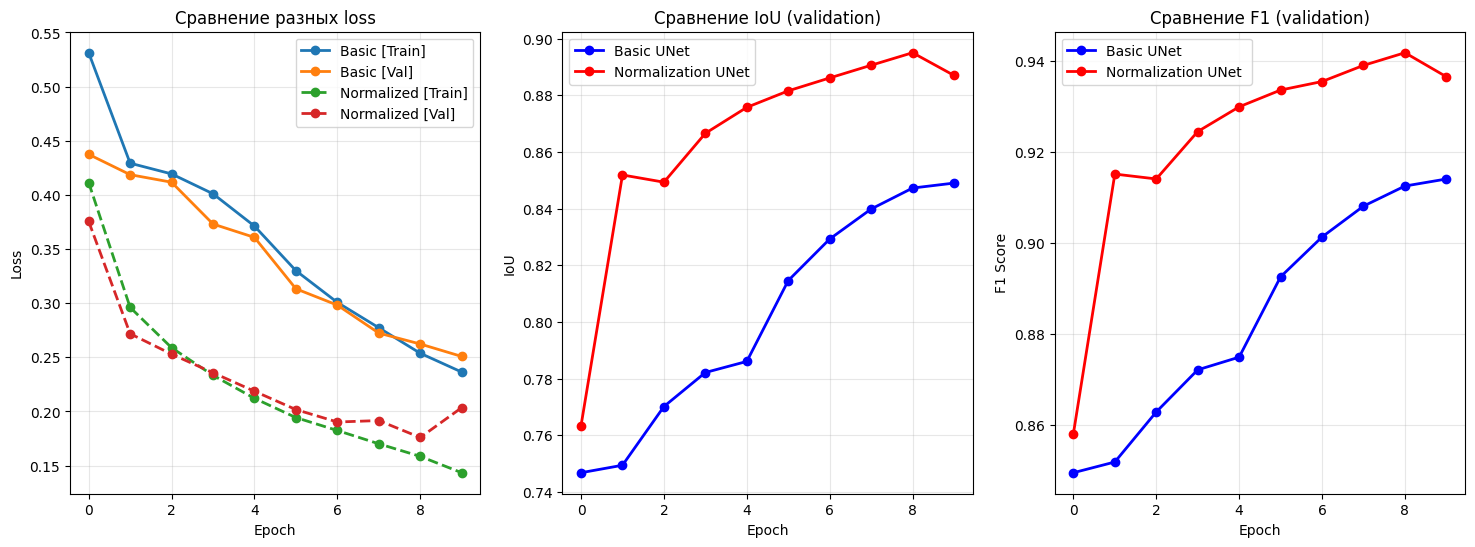

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# compare through history
ax[0].plot(history_without['train_loss'], label='Basic [Train]', marker='o', linewidth=2)
ax[0].plot(history_without['val_loss'], label='Basic [Val]', marker='o', linewidth=2)
ax[0].plot(history_with['train_loss'], label='Normalized [Train]', marker='o', linestyle='--', linewidth=2)
ax[0].plot(history_with['val_loss'], label='Normalized [Val]', marker='o', linestyle='--', linewidth=2)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Сравнение разных loss')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# iou compare
ax[1].plot(history_without['val_iou'], label='Basic UNet', marker='o', linewidth=2, color='b')
ax[1].plot(history_with['val_iou'], label='Normalization UNet', marker='o', linewidth=2, color='r')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU')
ax[1].set_title('Сравнение IoU (validation)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# f1 compare
ax[2].plot(history_without['val_f1'], label='Basic UNet', marker='o', linewidth=2, color='b')
ax[2].plot(history_with['val_f1'], label='Normalization UNet ', marker='o', linewidth=2, color='r')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('F1 Score')
ax[2].set_title('Сравнение F1 (validation)')
ax[2].legend()
ax[2].grid(True, alpha=0.3)



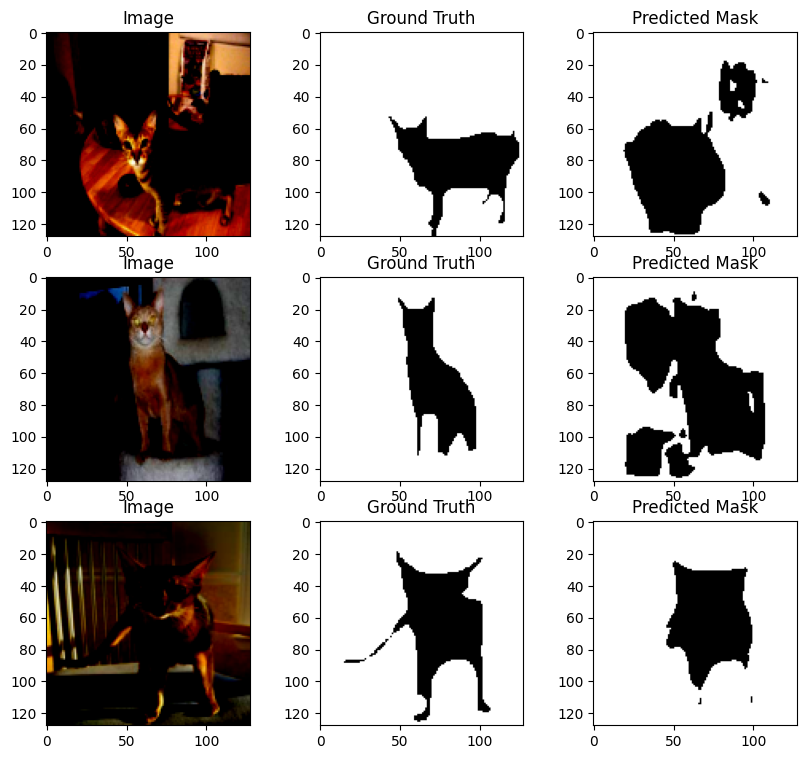

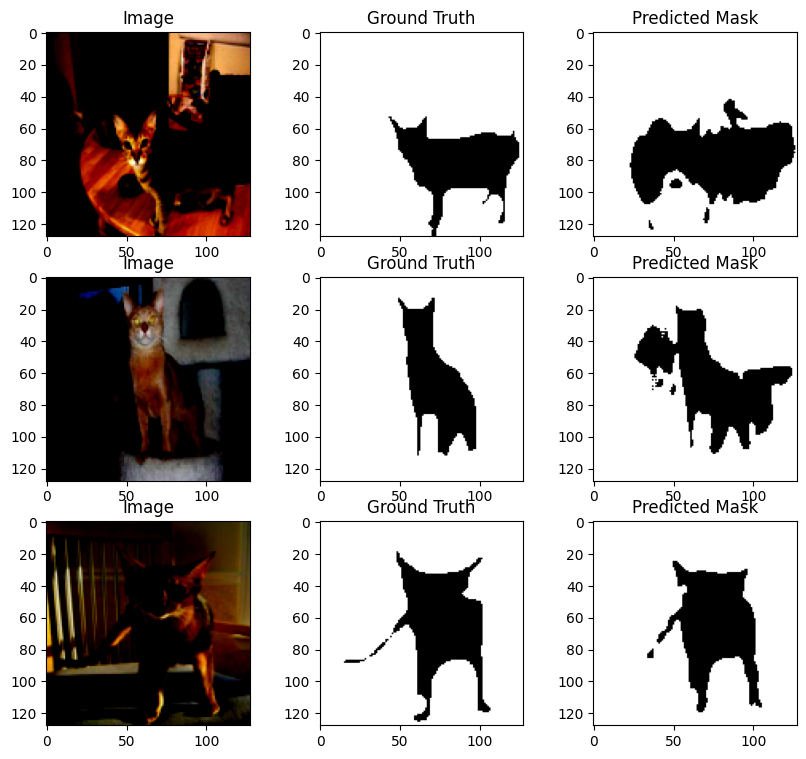

In [26]:
trainer_without.inference_and_plot_samples(n_samples=3)
trainer_with.inference_and_plot_samples(n_samples=3)

**Вывод по сравнению моделей:** нормализованная UNet показывает лучшие результаты на тех же параметрах обучения - это видно и из сравнения функции потерь, и из сравнения скоров F1 и IoU. Это связано с модификацией batch normalization, которая не только снижает риск переобучения, но и сглаживает функцию потерь (нормализует активации в батче).